In [11]:
import numpy as np
import matplotlib.pyplot as plt

# RK4 Implementation
See [Wikipedia](https://en.wikipedia.org/wiki/Runge%E2%80%93Kutta_methods) for more details.

In [85]:
def rk4(f: callable, t_n: float, y_n: float, dt: float):
    k_1 = dt * f(t_n, y_n)
    k_2 = dt * f(t_n + (dt/2), y_n + (k_1)*(dt/2))
    k_3 = dt * f(t_n + (dt/2), y_n + (k_2)*(dt/2))
    k_4 = dt * f(t_n + dt, y_n + dt*k_3)
    return y_n + (1/6)*(k_1 + 2 * k_2 + 2 * k_3 + k_4)

def solve(f: callable, t_0: float, t_f: float, y_0: float):
    h = 0.01
    y_n = y_0
    t_n = t_0
    
    n = (int)((t_f-t_0)/h) # Number of iterations
    t = np.zeros(n)
    y = np.zeros(n)
    t[0] = t_0
    y[0] = y_0

    for i in range(1, n):
        y_n = rk4(f, t_n, y_n, h)
        t[i] = t_n 
        y[i] = y_n
        t_n += h
    return t, y

def m(f: callable, g: callable, t_0: float, t_f: float, y_0: float, omega_0: float):
    h = 0.01
    n = (int)((t_f-t_0)/h) # Number of iterations

    t = np.zeros(n)
    theta = np.zeros(n)
    omega = np.zeros(n)

    t[0] = t_0
    theta[0] = y_0
    omega[0] =  omega_0

    t_n = t_0
    for i in range(1, n):
       
        k1_theta = h * f(omega[i-1])
        k1_omega = h * g(theta[i-1], omega[i-1])
        
        k2_theta = h * f(omega[i-1] + 0.5*k1_omega)
        k2_omega = h * g(theta[i-1] + 0.5*k1_theta, omega[i-1]+0.5*k1_omega)
        
        k3_theta = h * f(omega[i-1] + 0.5*k2_omega)
        k3_omega = h * g(theta[i-1] + 0.5*k2_theta, omega[i-1]+0.5*k2_omega)
        
        k4_theta = h * f(omega[i-1] + k3_omega)
        k4_omega = h * g(theta[i-1] + k3_theta, omega[i-1])
        
        theta[i] = theta[i-1] + (k1_theta + 2*k2_theta + 2*k3_theta + k4_theta)/6
        omega[i] = omega[i-1] + (k1_omega + 2*k2_omega + 2*k3_omega + k4_omega)/6

        t[i] = t_n
        t_n += h
    return t, theta, omega

    

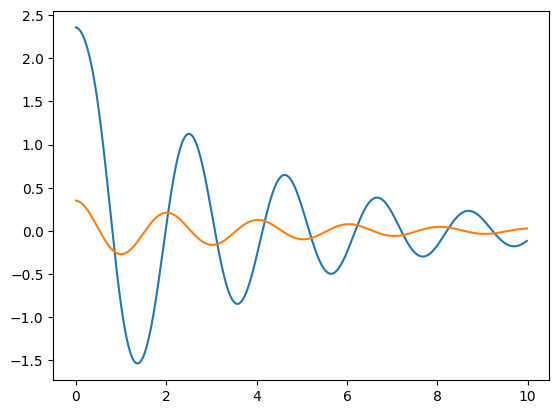

In [86]:
g = 9.81 #m/s^2
L = 1 #m

# change in angular frequency over time
def a(theta, omega):
    B = 0.5
    return -(g/L) * np.sin(theta) - B * omega

# change in theta over time
def x(omega):
    return omega


# t, y = solve(x, 0, 10, np.deg2rad(20))
t2, theta, omega = m(x, a, 0, 10, np.deg2rad(135), 0)
t2, theta2, omega2 = m(x, a, 0, 10, np.deg2rad(20), 0)
plt.plot(t2, theta)
plt.plot(t2, theta2)